# Canadian Real Estate Market Analysis

## Objective

The objective of this project is to analyze housing market data across Canada to identify pricing patterns based on property characteristics such as location, number of bedrooms, bathrooms, and square footage.

This analysis aims to answer the following questions:

- How does housing price vary based on property size and bedroom count?
- Which provinces and cities have the highest average housing prices?
- Is there a relationship between square footage and housing price?
- How is price per square foot distributed across the market?

## Dataset Information

The dataset contains Canadian real estate listings with property information such as:

- City
- Province
- Price
- Bedrooms
- Bathrooms
- Square Footage
- Property Type

The data was collected from Remax Canada real estate listings and published on Kaggle.

- Source: Remax Canada
- Collection Date: February 16, 2025

## Tools

- Python
- pandas
- matplotlib
- seaborn
- Google Colab

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
BASE_PATH = '/content/drive/MyDrive/TripleTen/Projects/Canadian_Housing_Market_Analysis'
DATA_PATH = f'{BASE_PATH}/Dataset/cleaned_canada.csv'

df = pd.read_csv(DATA_PATH, sep=',', engine='python', on_bad_lines='skip')
df.head()




,City,Province,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Property Type,Square Footage,...,Exterior,Fireplace,Heating,Flooring,Roof,Waterfront,Sewer,Pool,Garden,Balcony
0,Revelstoke,BC,50.976585,-118.173149,839000.0,3.0,2.0,0.00,Condo,891.0,...,NaN,No,heat pump,carpet,NaN,No,municipal,No,No,No
1,Boswell,BC,49.471870,-116.770195,1150000.0,3.0,2.0,0.32,Single Family,1881.0,...,NaN,No,heat pump,NaN,NaN,No,septic,No,No,No
2,West Kelowna,BC,49.825230,-119.603253,149000.0,2.0,1.0,0.00,Single Family,912.0,...,Metal,No,NaN,laminate,tar,No,municipal,No,No,No
3,Kelowna,BC,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,Single Family,4374.0,...,NaN,Yes,forced air,NaN,NaN,No,municipal,No,No,No
4,Maple Ridge,BC,49.221673,-122.596637,759900.0,3.0,2.0,0.00,Condo,1254.0,...,NaN,No,radiant,NaN,NaN,No,none,No,No,No


Some rows contained inconsistent numbers of fields due to formatting issues in the CSV file. These rows were skipped during loading to prevent parsing errors.

## Data Overview

Before beginning the analysis, the dataset structure and data quality were reviewed to identify missing values, data types, and available variables.

In [2]:
# Dataset dimensions
print("Rows and columns:", df.shape)

# Available variables
df.columns

Rows and columns: (44787, 23)


Index(['City', 'Province', 'Latitude', 'Longitude', 'Price', 'Bedrooms',
       'Bathrooms', 'Acreage', 'Property Type', 'Square Footage', 'Garage',
       'Parking', 'Basement', 'Exterior', 'Fireplace', 'Heating', 'Flooring',
       'Roof', 'Waterfront', 'Sewer', 'Pool', 'Garden', 'Balcony'],
      dtype='object')

In [3]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44787 entries, 0 to 44786
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            44787 non-null  object 
 1   Province        44787 non-null  object 
 2   Latitude        44787 non-null  float64
 3   Longitude       44787 non-null  float64
 4   Price           44787 non-null  float64
 5   Bedrooms        44787 non-null  float64
 6   Bathrooms       44787 non-null  float64
 7   Acreage         44787 non-null  float64
 8   Property Type   44787 non-null  object 
 9   Square Footage  44787 non-null  float64
 10  Garage          44787 non-null  object 
 11  Parking         44787 non-null  object 
 12  Basement        14872 non-null  object 
 13  Exterior        17415 non-null  object 
 14  Fireplace       44787 non-null  object 
 15  Heating         38142 non-null  object 
 16  Flooring        15111 non-null  object 
 17  Roof            9973 non-null  

In [4]:
# Missing values
df.isnull().sum()

,0
City,0
Province,0
Latitude,0
Longitude,0
Price,0
Bedrooms,0
Bathrooms,0
Acreage,0
Property Type,0
Square Footage,0


## Data Cleaning

To ensure data quality and improve the reliability of the analysis, the following cleaning steps will be performed:

- Select relevant variables for the analysis
- Identify missing and duplicate values
- Correct inconsistent bedroom and bathroom values
- Convert variables into numeric format
- Remove missing values
- Filter unrealistic observations and basic outliers

In [5]:
# Select relevant columns for analysis
housing = df[['City',
              'Province',
              'Price',
              'Bedrooms',
              'Bathrooms',
              'Property Type',
              'Square Footage']].copy()

housing.head()

,City,Province,Price,Bedrooms,Bathrooms,Property Type,Square Footage
0,Revelstoke,BC,839000.0,3.0,2.0,Condo,891.0
1,Boswell,BC,1150000.0,3.0,2.0,Single Family,1881.0
2,West Kelowna,BC,149000.0,2.0,1.0,Single Family,912.0
3,Kelowna,BC,1298000.0,5.0,4.0,Single Family,4374.0
4,Maple Ridge,BC,759900.0,3.0,2.0,Condo,1254.0


In [6]:
# Check for duplicated rows
housing.duplicated().sum()

np.int64(4559)

In [7]:
# Check missing values
housing.isnull().sum()

,0
City,0
Province,0
Price,0
Bedrooms,0
Bathrooms,0
Property Type,0
Square Footage,0


In [8]:
## Correct unusually large bedroom values
housing.loc[housing['Bedrooms'] > 10, 'Bedrooms'] = (
    housing.loc[housing['Bedrooms'] > 10, 'Bedrooms'] / 10
)

# Correct unusually large bathroom values
housing.loc[housing['Bathrooms'] > 10, 'Bathrooms'] = (
    housing.loc[housing['Bathrooms'] > 10, 'Bathrooms'] / 10
)

# Round corrected values
housing['Bedrooms'] = housing['Bedrooms'].round()
housing['Bathrooms'] = housing['Bathrooms'].round()

In [9]:
# Convert variables to numeric format
numeric_cols = [
    'Price',
    'Bedrooms',
    'Bathrooms',
    'Square Footage'
]

for col in numeric_cols:
    housing[col] = pd.to_numeric(
        housing[col],
        errors='coerce'
    )

In [10]:
# Remove missing values
housing = housing.dropna(
    subset=[
        'Price',
        'Bedrooms',
        'Bathrooms',
        'Square Footage'
    ]
)

In [11]:
# Dataset information after cleaning
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44787 entries, 0 to 44786
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            44787 non-null  object 
 1   Province        44787 non-null  object 
 2   Price           44787 non-null  float64
 3   Bedrooms        44787 non-null  float64
 4   Bathrooms       44787 non-null  float64
 5   Property Type   44787 non-null  object 
 6   Square Footage  44787 non-null  float64
dtypes: float64(4), object(3)
memory usage: 2.4+ MB


In [12]:
# Remove unrealistic values and simple outliers
housing = housing[
    (housing['Price'] > 100000) &
    (housing['Price'] < 5000000)
]

housing = housing[
    (housing['Bedrooms'] >= 1) &
    (housing['Bedrooms'] <= 10)
]

housing = housing[
    (housing['Bathrooms'] >= 1) &
    (housing['Bathrooms'] <= 10)
]

housing = housing[
    (housing['Square Footage'] > 0) &
    (housing['Square Footage'] < 15000)
]

In [13]:
# Final dataset dimensions
housing.shape

(42509, 7)

In [14]:
housing['Bedrooms'] = housing['Bedrooms'].astype(int)
housing['Bathrooms'] = housing['Bathrooms'].astype(int)

After the cleaning process, the dataset contains more consistent observations and fewer extreme values that could affect the analysis.

## Exploratory Data Analysis (EDA)
The goal of this section is to explore housing trends and identify patterns between property characteristics and housing prices.

The analysis focuses on:

- Average price by number of bedrooms
- Property distribution by bedroom count
- Housing price distribution
- Relationship between square footage and price

### Average Housing Price by Bedroom Count

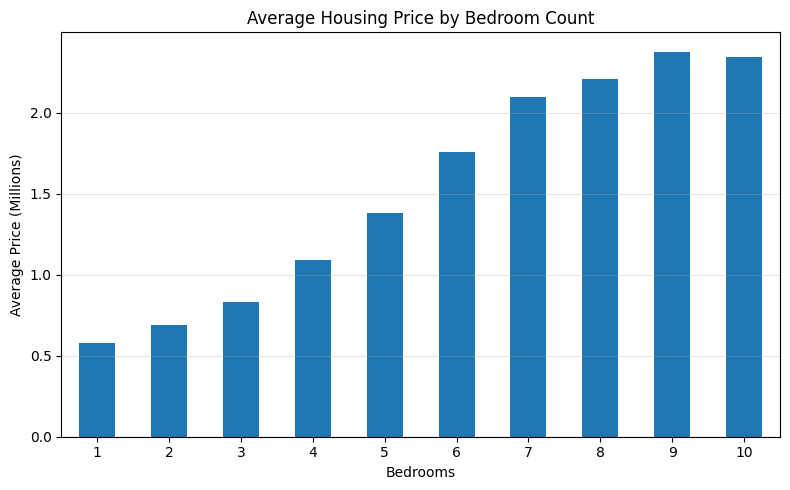

In [15]:
# Average housing price by bedroom count
avg_price_bedrooms = (
    housing.groupby('Bedrooms')['Price']
    .mean()
    .sort_index()
)

# Convert prices to millions
avg_price_bedrooms_m = avg_price_bedrooms / 1000000

# Create visualization
plt.figure(figsize=(8,5))

avg_price_bedrooms_m.plot(
    kind='bar'
)

plt.title(
    'Average Housing Price by Bedroom Count'
)

plt.xlabel(
    'Bedrooms'
)

plt.ylabel(
    'Average Price (Millions)'
)

plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()


Housing prices show a positive relationship with bedroom count. Properties with more bedrooms generally have higher average prices.

Homes with seven or more bedrooms tend to exceed CAD 2 million, suggesting that larger properties belong primarily to the higher-end market segment.

### Property Distribution by Bedroom Count

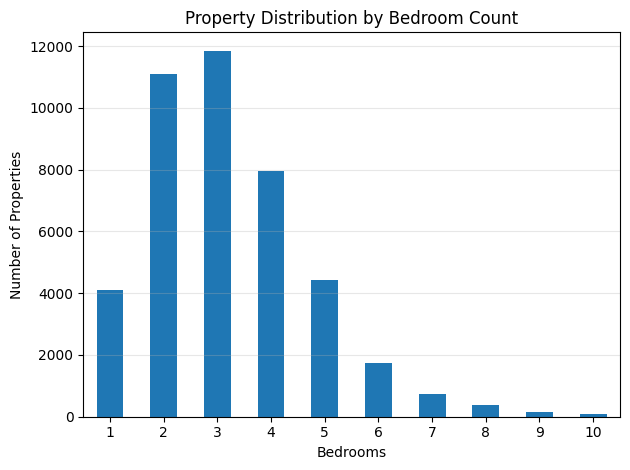

In [16]:
# Number of properties by bedroom count
housing['Bedrooms']\
.value_counts()\
.sort_index()\
.plot(kind='bar')

plt.title(
    'Property Distribution by Bedroom Count'
)

plt.xlabel(
    'Bedrooms'
)

plt.ylabel(
    'Number of Properties'
)

plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

Most properties are concentrated between two and four bedrooms, suggesting that this is the most common housing configuration in the market.

Properties with seven or more bedrooms are considerably less frequent, indicating that large homes represent a smaller niche segment.

### Housing Price Distribution

The following visualization explores how housing prices are distributed across the dataset and identifies where most properties are concentrated.

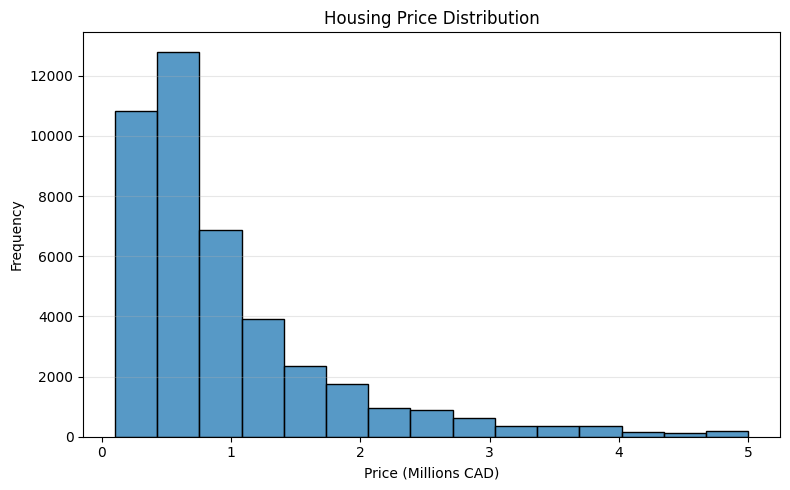

In [17]:
# Convert prices to millions
housing['Price_m'] = housing['Price'] / 1000000

# Create histogram
plt.figure(figsize=(8,5))

sns.histplot(
    housing['Price_m'],
    bins=15
)

plt.title(
    'Housing Price Distribution'
)

plt.xlabel(
    'Price (Millions CAD)'
)

plt.ylabel(
    'Frequency'
)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

plt.show()

Most properties appear concentrated in lower and mid-price ranges, while fewer properties exist at higher price levels.

The distribution is right-skewed, suggesting that high-value properties are less common but extend the overall price range.

### Property Size and Housing Price

The following chart examines the relationship between property size and housing price to determine whether larger homes tend to cost more.

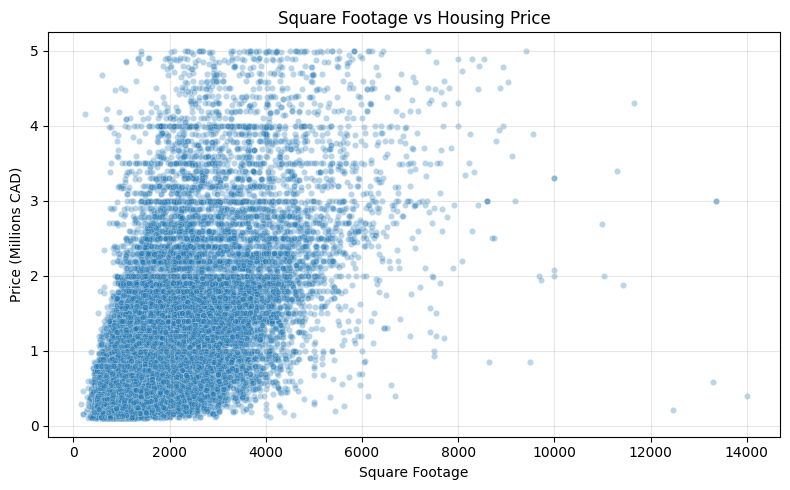

In [18]:
# Relationship between property size and price

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=housing,
    x='Square Footage',
    y='Price_m',
    alpha=0.3,
    s=20
)

plt.title(
    'Square Footage vs Housing Price'
)

plt.xlabel(
    'Square Footage'
)

plt.ylabel(
    'Price (Millions CAD)'
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

The scatter plot suggests a positive relationship between property size and price.

Larger homes generally tend to be more expensive; however, considerable variation exists, indicating that additional factors such as location, property condition, and amenities may also influence pricing.

## Geographic and Business Insights
### Average Housing Price by Province

This analysis compares average housing prices across Canadian provinces to identify higher-cost housing markets.

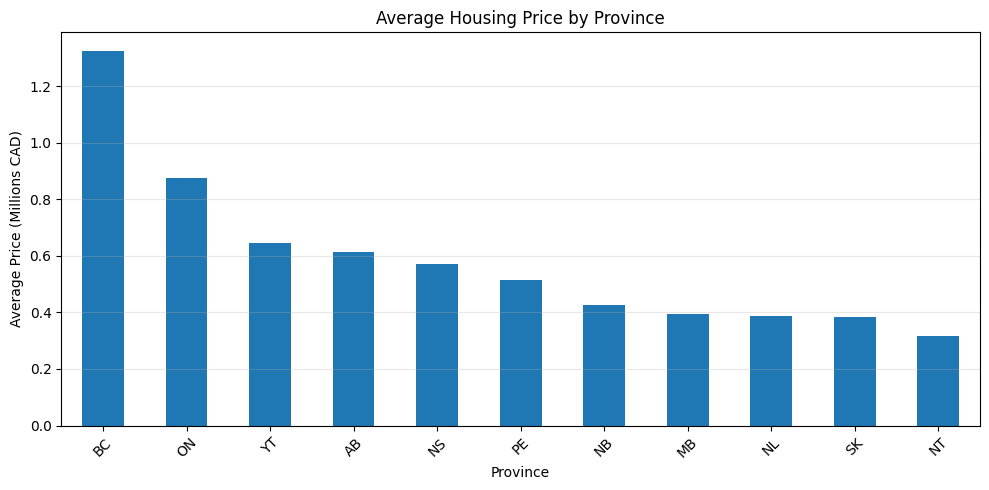

In [19]:
# Average housing price by province
avg_price_province = (
    housing.groupby('Province')['Price']
    .mean()
    .sort_values(ascending=False)
) / 1000000

plt.figure(figsize=(10,5))

avg_price_province.plot(
    kind='bar'
)

plt.title(
    'Average Housing Price by Province'
)

plt.xlabel(
    'Province'
)

plt.ylabel(
    'Average Price (Millions CAD)'
)

plt.xticks(rotation=45)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

plt.show()

British Columbia shows the highest average housing prices among the provinces included in the dataset, standing considerably above the national average.

Ontario appears as the second most expensive province, suggesting strong housing markets in major urban areas across both provinces.

In contrast, lower average prices are observed in provinces and territories such as the Northwest Territories (NT), suggesting regional differences in housing demand, population density, and market conditions.

These differences may reflect factors such as economic activity, desirability, and housing availability across regions.


### Top 10 Most Expensive Cities

The following analysis identifies the Canadian cities with the highest average housing prices.

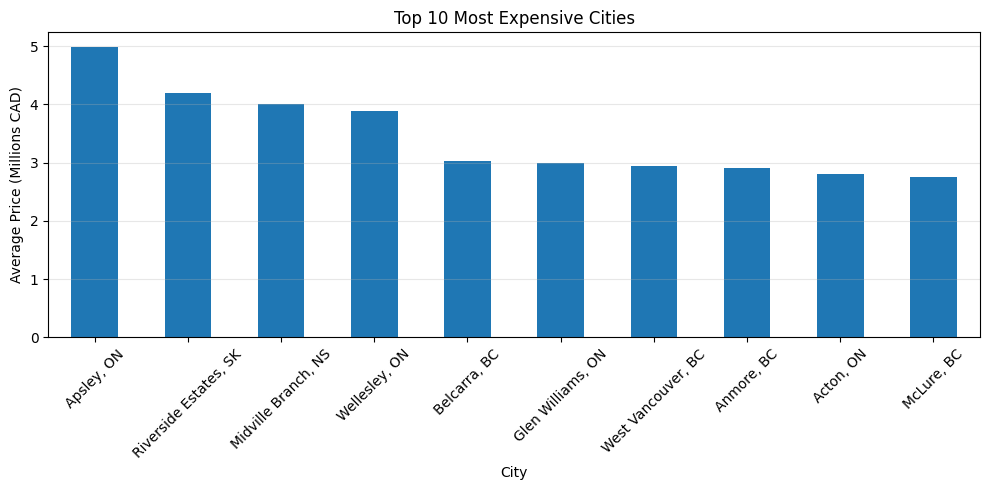

In [20]:
# Create city-province label
housing['City_Province'] = (
    housing['City'] +
    ', ' +
    housing['Province']
)
# Top 10 most expensive cities
top_cities = (
    housing.groupby('City_Province')['Price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
) / 1000000

plt.figure(figsize=(10,5))

top_cities.plot(
    kind='bar'
)

plt.title(
    'Top 10 Most Expensive Cities'
)

plt.xlabel(
    'City'
)

plt.ylabel(
    'Average Price (Millions CAD)'
)

plt.xticks(rotation=45)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

plt.show()

Several of the most expensive cities are located in British Columbia and Ontario, reinforcing the strong housing markets observed in these provinces.

The concentration of high-priced cities in these regions may reflect higher demand, larger urban populations, and more competitive housing markets.

### Price per Square Foot Distribution

Price per square foot is a useful metric for comparing housing value while accounting for property size.

This analysis shows how price per square foot is distributed across the dataset.

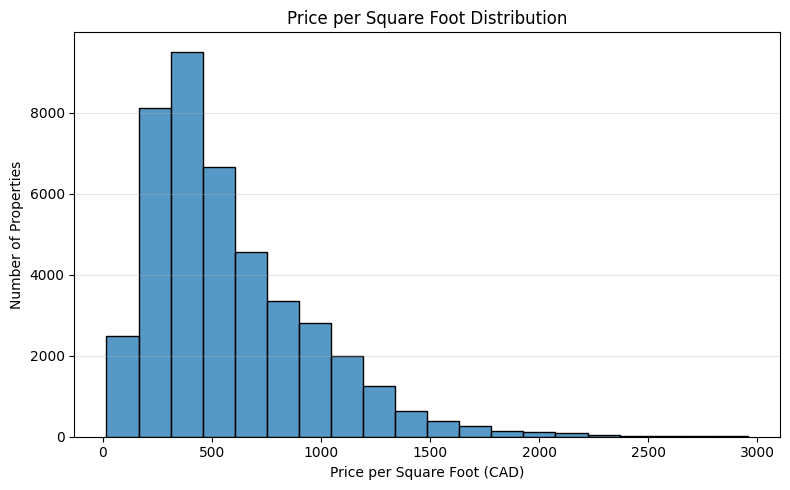

In [21]:
# Calculate price per square foot
housing['Price_per_sqft'] = (
    housing['Price'] / housing['Square Footage']
)

# Remove extreme price per square foot outliers
housing_ppsqft = housing[
    housing['Price_per_sqft'] < 3000
]

# Create histogram
plt.figure(figsize=(8,5))

sns.histplot(
    housing_ppsqft['Price_per_sqft'],
    bins=20
)

plt.title('Price per Square Foot Distribution')
plt.xlabel('Price per Square Foot (CAD)')
plt.ylabel('Number of Properties')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

A small number of extreme values were excluded from the visualization to improve readability and better represent the overall market distribution.

Most properties are concentrated within lower and moderate price-per-square-foot ranges.

This suggests that property value is influenced not only by size, but also by factors such as location, market demand, and property characteristics.

## Conclusions

This analysis explored housing market patterns across Canada using property characteristics such as bedrooms, bathrooms, square footage, city, and province.

The results showed a clear positive relationship between property size and housing price. Properties with a greater number of bedrooms and larger square footage generally tend to have higher prices, particularly within higher-end housing segments.

The analysis also revealed that most properties in the dataset are concentrated between two and four bedrooms, suggesting that medium-sized homes represent the largest share of the market inventory.

From a geographic perspective, British Columbia and Ontario showed the highest average housing prices among the provinces included in the dataset. In addition, many of the most expensive cities identified in the analysis were located within these provinces, highlighting stronger housing markets and higher property values in major urban regions.

The price-per-square-foot analysis demonstrated that most properties are concentrated within lower to moderate ranges, while a smaller number of premium properties extend the market toward significantly higher values. This indicates that factors beyond property size, such as location, demand, and market conditions, also play an important role in housing valuation.

Overall, the analysis demonstrates how exploratory data analysis can help identify housing market trends, regional pricing differences, and property characteristics associated with higher housing values. These insights may support buyers, investors, and real estate professionals in understanding market behavior and comparing housing opportunities across Canadian regions.

# Recommendations

Based on the analysis, the following areas may be valuable for further exploration:

- Conduct deeper analysis by city and neighborhood to better understand local housing market variations.
- Include additional variables such as property age, income levels, or proximity to urban centers to improve pricing insights.
- Explore time-series data to analyze housing market trends over time.
- Develop interactive dashboards to help users compare housing prices across provinces and cities more efficiently.

In [22]:
housing.to_csv('cleaned_canadian_housing_analysis.csv', index=False)

In [23]:
from google.colab import files
files.download('cleaned_canadian_housing_analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>